In [10]:
import pandas as pd
import cv2
import numpy as np
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

from src.blank_detect import is_blank

In [2]:
BASE_DIR = Path.cwd()
CSV_PATH = BASE_DIR / "data" / "output" / "dataset" / "labels.csv"
IMG_DIR = BASE_DIR / "data" / "output" / "dataset" / "images"

In [3]:
df = pd.read_csv(CSV_PATH)

images = []
labels = df["is_blank"].values

In [4]:
for filename in df["filename"]:
    img_path = str(IMG_DIR / filename)
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) 
    
    if img is None:
        print(f"Warning: Could not read {img_path}")
        continue
        
    images.append(img)

In [5]:
X_data = np.array(images)
y_data = labels

print(f"Images array shape: {X_data.shape}")
print(f"Labels array shape: {y_data.shape}")

Images array shape: (5000, 500, 500)
Labels array shape: (5000,)


In [6]:
import numpy as np
import cv2
from sklearn.ensemble import RandomForestClassifier
from strategies.preprocessor import BlankDetector
import joblib
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_data, 
    y_data, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_data
)

print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Test set:  {X_test.shape}, {y_test.shape}")

print(f"Training blank ratio: {y_train.mean():.2%}")
print(f"Testing blank ratio:  {y_test.mean():.2%}")

print("Extracting features from training set...")
X_train_features = np.array([BlankDetector.extract_blank_features(img) for img in X_train])

print("Extracting features from test set...")
X_test_features = np.array([BlankDetector.extract_blank_features(img) for img in X_test])

print(f"New X_train shape: {X_train_features.shape}")
print(f"New X_test shape:  {X_test_features.shape}")

print(f"Old X_train shape: {X_train_features.shape}")

X_train_features = X_train_features.reshape(X_train_features.shape[0], 3)
X_test_features = X_test_features.reshape(X_test_features.shape[0], 3)

print(f"Fixed X_train shape: {X_train_features.shape}")

clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf.fit(X_train_features, y_train)

joblib.dump(clf, "models/rf_blank_detector.joblib")
print("Training complete & Model saved!")

Train set: (4000, 500, 500), (4000,)
Test set:  (1000, 500, 500), (1000,)
Training blank ratio: 60.15%
Testing blank ratio:  60.20%
Extracting features from training set...
Extracting features from test set...
New X_train shape: (4000, 1, 3)
New X_test shape:  (1000, 1, 3)
Old X_train shape: (4000, 1, 3)
Fixed X_train shape: (4000, 3)
Training complete & Model saved!


In [7]:
y_pred = clf.predict(X_test_features)
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     1.0000    0.9372    0.9676       398
           1     0.9601    1.0000    0.9797       602

    accuracy                         0.9750      1000
   macro avg     0.9801    0.9686    0.9736      1000
weighted avg     0.9760    0.9750    0.9748      1000



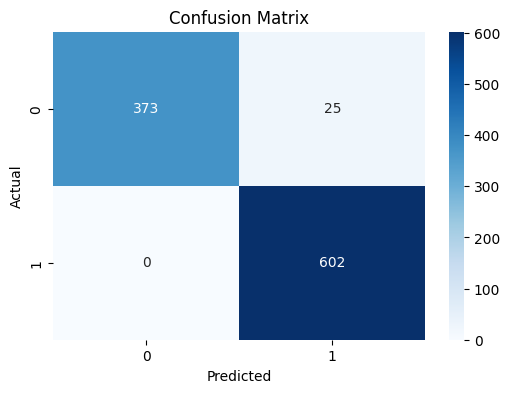

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [13]:
from scipy.spatial.distance import cdist
import numpy as np

# Features test gần features train cỡ nào?
X_test_features = X_test_features.reshape(X_test_features.shape[0], 3)
train_features = X_train_features

distances = cdist(X_test_features, train_features, metric='euclidean')
nearest = distances.min(axis=1)

print(f"Nearest distance — mean: {nearest.mean():.6f}")
print(f"Nearest distance — min:  {nearest.min():.6f}")
print(f"Nearest distance — max:  {nearest.max():.6f}")
print(f"Số sample test có khoảng cách < 0.001: {(nearest < 0.001).sum()}")
print(f"Số sample test có khoảng cách < 0.01:  {(nearest < 0.01).sum()}")

Nearest distance — mean: 0.042476
Nearest distance — min:  0.000000
Nearest distance — max:  0.614920
Số sample test có khoảng cách < 0.001: 189
Số sample test có khoảng cách < 0.01:  324
